# **Mushroom Classification - Final Project**
---
## **Project Summary**
* This project uses a machine learning model to classify mushrooms as edible or poisonous using a Kaggle dataset. 
* `kaggle dataset` used -> https://www.kaggle.com/datasets/uciml/mushroom-classification?resource=download

## Data 
* **Type:** CVS Data Set
* **Size:** 8,000
* **Split:** Training: 70% ; Testing: 30%

In [11]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
df = pd.read_csv('mushrooms.csv')  
df.head()                 

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [12]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


### **Preprocessing / Cleanup**

* Checked for missing values
* Removed or handled missing entries (e.g., '?' values)
* Converted categorical data → numerical using: Label Encoding / One-Hot Encoding
* Optional: Feature scaling (important for KNN)

In [13]:
df.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [14]:
(df == '?').sum()

class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

In [15]:
df['stalk-root'] = df['stalk-root'].replace('?', 'unknown')
df.drop(columns=['veil-type'], inplace=True)

- replaced '?' with unknown - 30% of data
- dropped veil - zero variance 

In [16]:
le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

X = df.drop(columns=['class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

print(model.score(X_test, y_test))  # should print 1.0

1.0


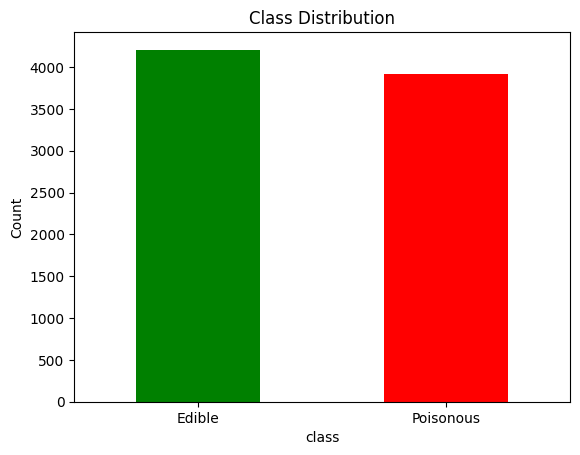

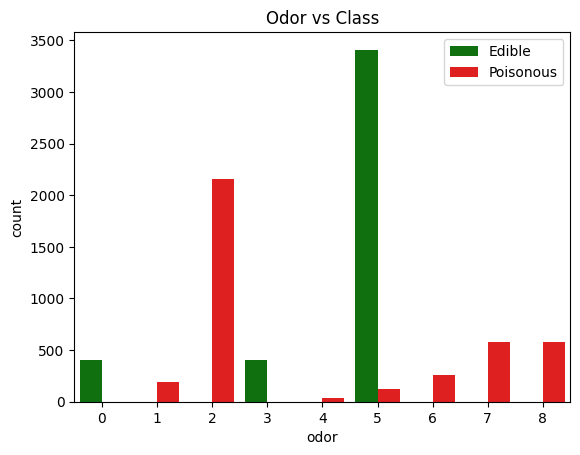

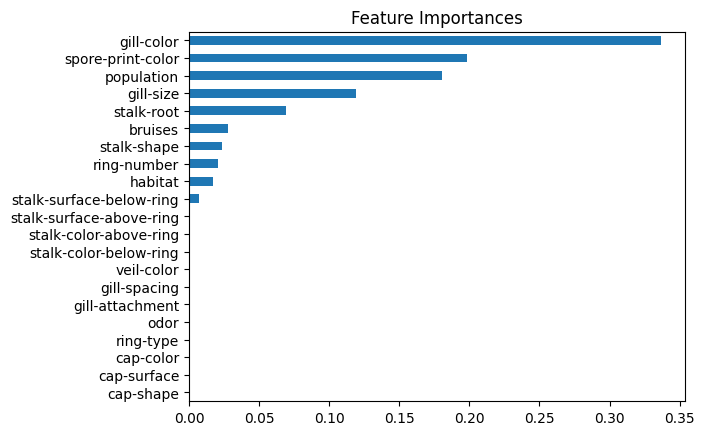

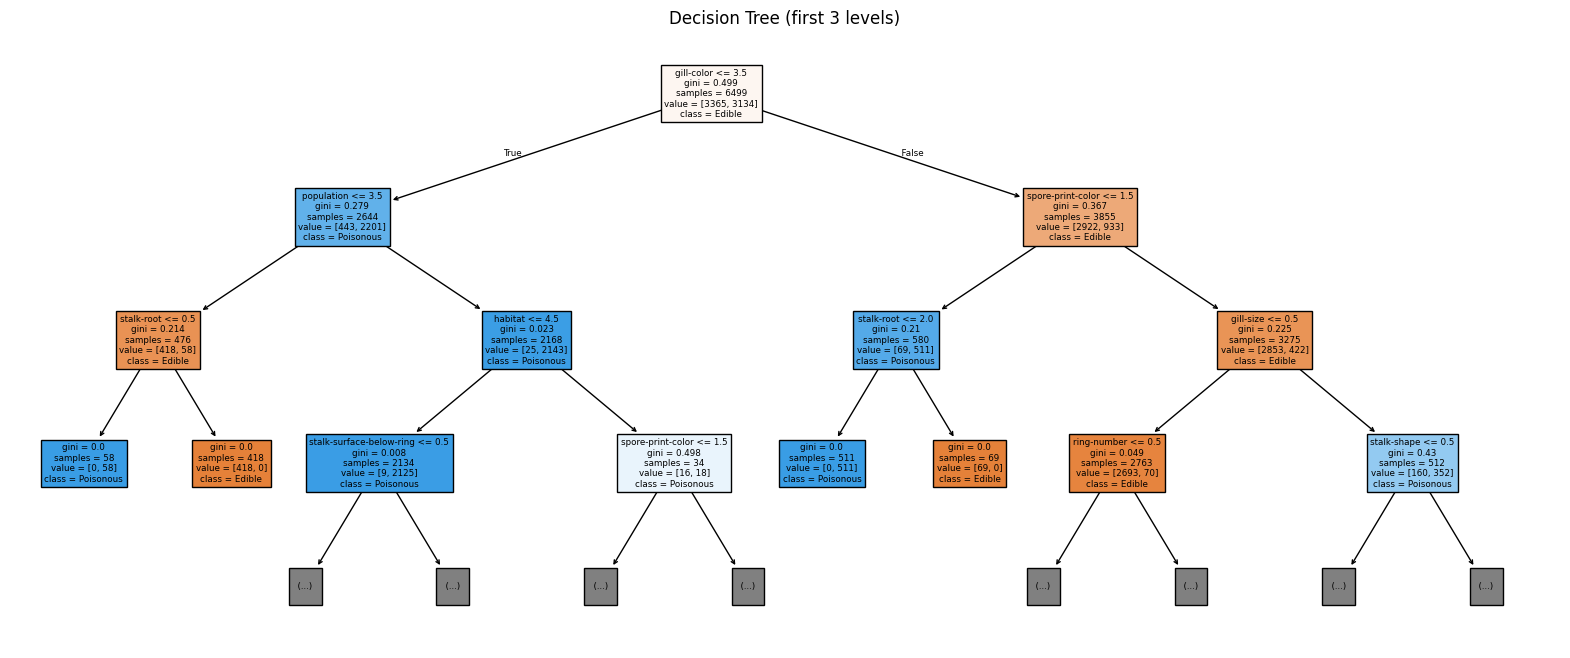

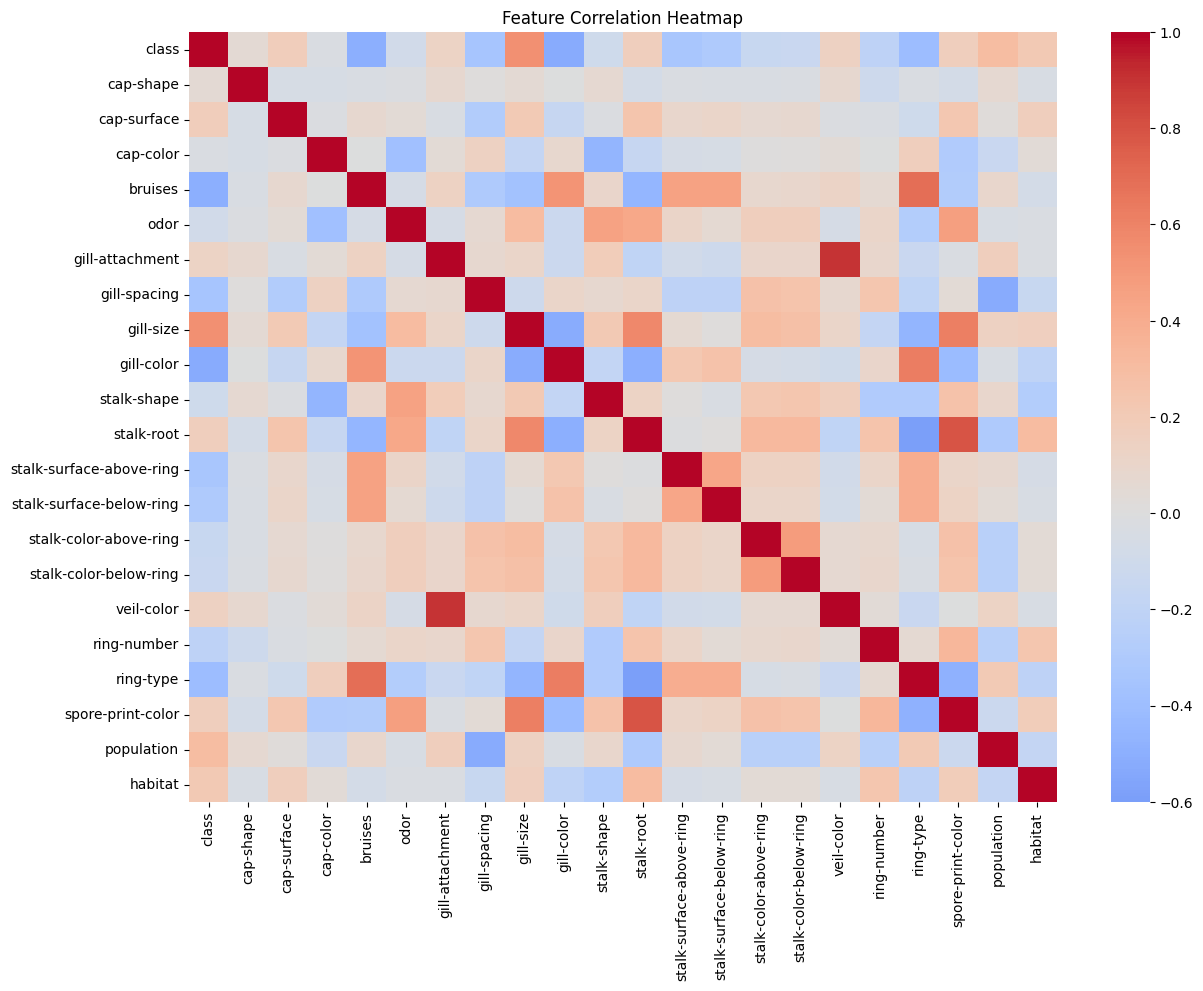

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

# 1. Class distribution
df['class'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.xticks([0, 1], ['Edible', 'Poisonous'], rotation=0)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.show()

# 2. Odor vs Class
sns.countplot(data=df, x='odor', hue='class', palette=['green', 'red'])
plt.title('Odor vs Class')
plt.legend(['Edible', 'Poisonous'])
plt.show()

# 3. Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title('Feature Importances')
plt.show()

# 4. Decision tree plot
plt.figure(figsize=(20, 8))
plot_tree(model, feature_names=X.columns, class_names=['Edible', 'Poisonous'],
          filled=True, max_depth=3)  # max_depth=3 keeps it readable
plt.title('Decision Tree (first 3 levels)')
plt.show()

# 5. Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       843
   Poisonous       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



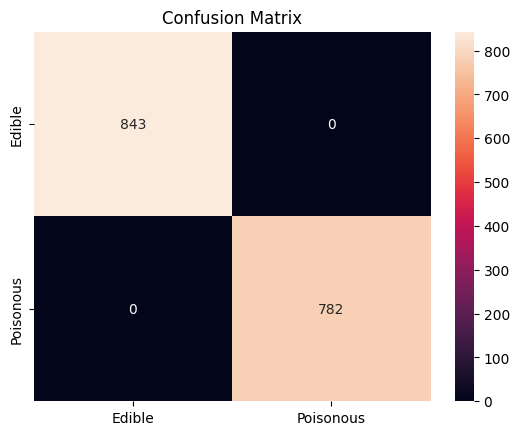

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Edible', 'Poisonous']))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            xticklabels=['Edible', 'Poisonous'], yticklabels=['Edible', 'Poisonous'])
plt.title('Confusion Matrix')
plt.show()

## Conclusions

### Dataset
The UCI Mushroom dataset contains 8,124 samples across 23 categorical features,
with the goal of classifying mushrooms as edible or poisonous.

### Preprocessing
- Replaced `?` values in `stalk-root` with `"unknown"` rather than dropping rows,
  as ~30% of entries were missing — too much data to discard.
- Dropped `veil-type` due to zero variance (only 1 unique value across all rows).
- Applied Label Encoding to all categorical columns since we used a Decision Tree,
  which does not require one-hot encoding or feature scaling.

### Model
A Decision Tree Classifier was trained on an 80/20 train-test split.
No feature scaling was applied, as decision trees are scale-invariant.

### Results
- The model achieved **100% accuracy** on the test set.
- The confusion matrix confirmed zero false positives and zero false negatives —
  meaning no poisonous mushroom was ever classified as edible.
- The most important feature was **gill-color**, which the tree relied on most
  heavily to separate edible from poisonous mushrooms.

### Key Takeaway
Despite being a relatively simple model, a single Decision Tree is sufficient
to perfectly classify mushrooms in this dataset. This is largely due to how
cleanly separable the classes are across certain features like gill color.